# Dwarf Galaxies in VFS Halpha Survey

In [2]:
import os
from matplotlib import pyplot as plt
import numpy as np
from astropy.table import Table
import glob
import warnings
warnings.filterwarnings('ignore')

homedir = os.getenv("HOME")
plotdir = homedir + "/research/Virgo/hapypost/plots/"

# TODO

- [x] cumulative distribution of redshifts for dwarfs in each environment category
- [ ] redo plot but w/SFR based on SEDs
  - [ ] main sequence fit
  - [ ] sf is within 0.3 dex of the MS
  - [ ] quiescent is >0.3 dex below MS

# Redshift Distribution of Dwarfs vs Environment

table directory = /Users/rfinn/research/Virgo/tables-north/v2/


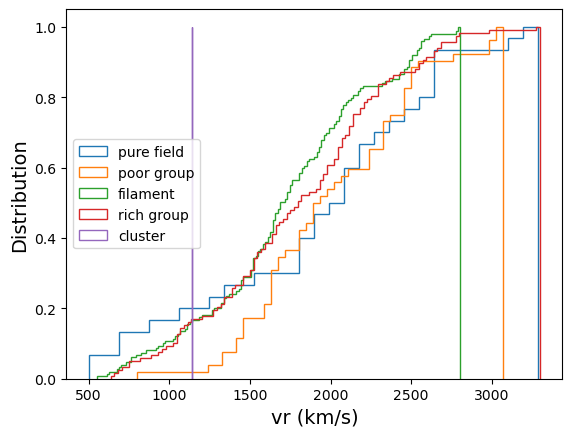

In [65]:
%run ~/github/hapypost/scripts/dwarf_galaxies.py --tabledir ~/research/Virgo/tables-north/v2/ --plotdir $plotdir

plot_dwarf_redshift_by_environment(
    v,
    plotdir,
    outfile_root="dwarf_redshift_by_environment",
    haobs_key="HAPY_HAS_OBS",
    show=True,
    title=True,
    logmstar_min=6.5,
    logmstar_max=8.5,
)

# Fraction of Halpha Detections vs Environment

table directory = /Users/rfinn/research/Virgo/tables-north/v2/
number of dwarf galaxies observed with Halpha = 318
number of dwarf galaxies detected with Halpha = 143


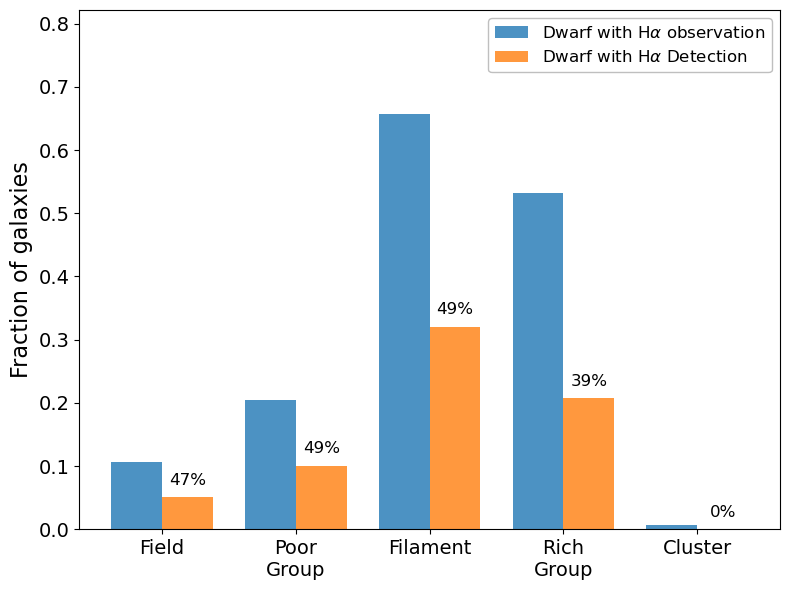

In [132]:
%run ~/github/hapypost/scripts/dwarf_galaxies.py --tabledir ~/research/Virgo/tables-north/v2/ --plotdir $plotdir
plot_environment_distribution(v, plotdir,show=True, logmstar_min=7.)


table directory = /Users/rfinn/research/Virgo/tables-north/v2/


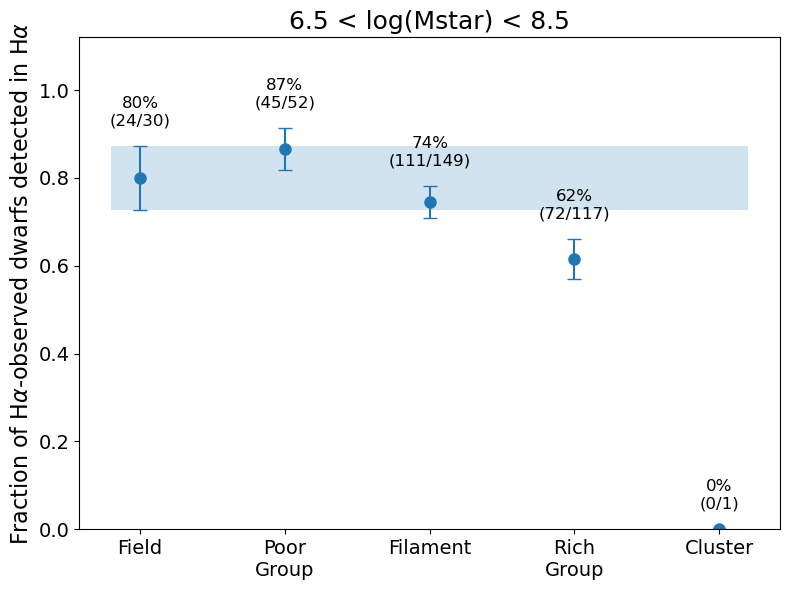

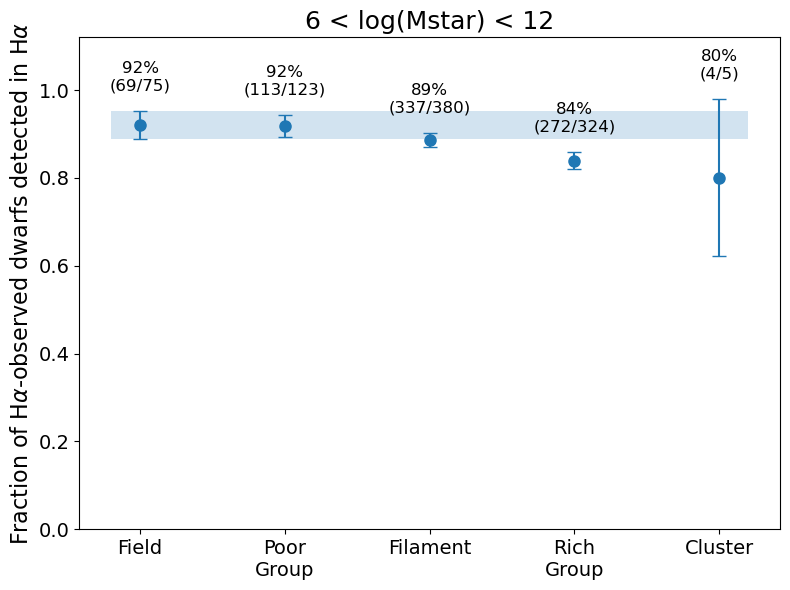

In [139]:
%run ~/github/hapypost/scripts/dwarf_galaxies.py --tabledir ~/research/Virgo/tables-north/v2/ --plotdir $plotdir
SNR_CUT=3.5
NPIX = 1
t = plot_halpha_detection_completeness_by_environment(
    v,
    plotdir,
    outfile_root="dwarf_halpha_detection_completeness_by_environment",
    haobs_key="HAPY_HAS_OBS",
    show=True,
    title=True,
    logmstar_min=6.5,
    logmstar_max=8.5,
    ha_snr_cut=SNR_CUT,
    npix=NPIX,
)


t = plot_halpha_detection_completeness_by_environment(
    v,
    plotdir,
    outfile_root="dwarf_halpha_detection_completeness_by_environment",
    haobs_key="HAPY_HAS_OBS",
    show=True,
    title=True,
    logmstar_min=6,
    logmstar_max=12,
    ha_snr_cut=SNR_CUT,
    npix=NPIX,
)

# SFR-Mstar Relation

table directory = /Users/rfinn/research/Virgo/tables-north/v2/


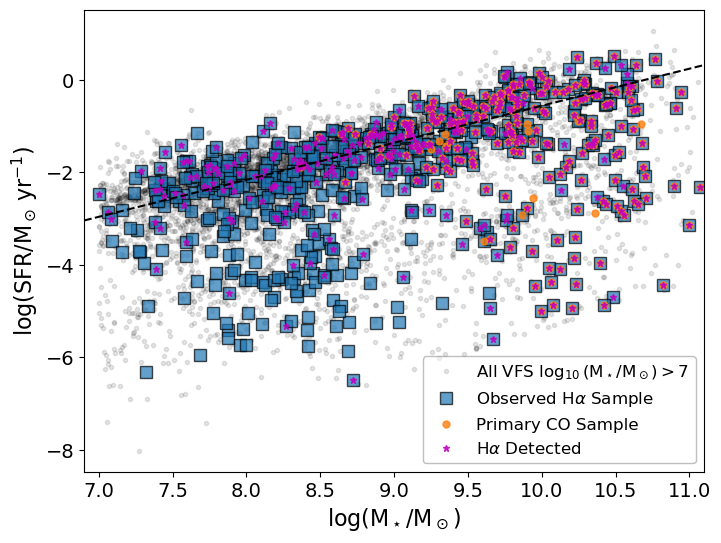

In [127]:
%run ~/github/hapypost/scripts/dwarf_galaxies.py --tabledir ~/research/Virgo/tables-north/v2/ --plotdir $plotdir
plot_sfr_mstar_sample(v, plotdir)
#plt.show()

# Select dwarfs on MS but no halpha detection

In [123]:
logmstar = get_mstar(v)
logsfr = get_sfr(v)
dsfr = get_dsfr(logmstar,logsfr)

ms_flag = np.abs(dsfr) < 1


dwarf_flag = get_dwarf_flag(v,logmstar_min=7.5,logmstar_max=8.5)
ha_detect_flag = get_halpha_detection_flag(v,snr_cut=3.9)
has_ha = v.halpha['HAPY_HAS_OBS']


# MS dwarfs with no halpha
ms_dwarf_no_ha = dwarf_flag & ms_flag & has_ha & ~ha_detect_flag

print(f"number of MS dwarfs with no halpha = {np.sum(ms_dwarf_no_ha)}")

number of MS dwarfs with no halpha = 38


In [121]:
np.arange(len(v.main))[ms_dwarf_no_ha]

array([1168, 1587, 1832, 1912, 2049, 2098, 2175, 2660, 2671, 2738, 2766,
       2792, 3014, 3020, 3035, 3202, 3251, 3297, 3362, 3369, 3446, 3475,
       3483, 3490, 3491, 3493, 3504, 3674, 3712, 4081, 4104, 4257, 5844,
       5952, 6194, 6327, 6338, 6372, 6386, 6392, 6428, 6512])

In [109]:
ha_detect_flag[582]

True

In [110]:
v.main['VFID'][582]

'VFID0582'

In [111]:
v.halpha['CSGR_HAPY_SNP_DET'][582] > 5

False

In [112]:
# 2049 is an example of blue but no halpha
# what is stellar mass?
logmstar[2049]

8.291269650933524

In [117]:
ha_detect_flag[2049]

False

In [118]:
dsfr[2049]

-0.9244353066828919

In [126]:
v.main['vr'][2175]

1276.0